# Phase 2 — Exploratory Data Analysis (EDA)
### Early Disease Prediction Using Healthcare Data Warehouse

**Objective:** Deeply understand each dataset's distributions, class imbalances,
feature relationships, and statistical associations *before* any modelling.

| Dataset | Records | Features | Target | Imbalance |
|---|---|---|---|---|
| Autism Screening | 6,075 | 16 | ASD Diagnosis (1=YES) | ~1 : 2.4 (mild) |
| Diabetes Risk | 520 | 17 | Diabetic (1=Positive) | ~1 : 1.6 (mild) |
| Stroke Prediction | 5,109 | 11 | Stroke (1=Yes) | ~1 : 19.5 (**severe**) |

All figures are saved automatically to `reports/figures/`.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import matplotlib.ticker    as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

# ── Plot style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'      : 110,
    'figure.facecolor': 'white',
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'axes.titleweight': 'bold',
})
PALETTE = {'pos': '#E05C5C', 'neg': '#4878CF',
           'autism': '#5B9BD5', 'diabetes': '#70AD47', 'stroke': '#FF6B6B'}

# ── Path resolution ─────────────────────────────────────────────────────
#    Works whether Jupyter is launched from the project root or eda/
_cwd  = Path.cwd()
ROOT  = _cwd.parent if _cwd.name == 'eda' else _cwd
CLEAN = ROOT / 'datasets' / 'cleaned'
FIGS  = ROOT / 'reports'  / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

def savefig(fname: str) -> None:
    plt.savefig(FIGS / fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  [SAVED] reports/figures/{fname}')

print('ROOT       :', ROOT)
print('Figures dir:', FIGS)

ROOT       : D:\NMU\Data Mining\Early Disease Prediction Using Healthcare Data Warehouse
Figures dir: D:\NMU\Data Mining\Early Disease Prediction Using Healthcare Data Warehouse\reports\figures


In [2]:
df_a = pd.read_csv(CLEAN / 'autism_cleaned.csv')
df_d = pd.read_csv(CLEAN / 'diabetes_cleaned.csv')
df_s = pd.read_csv(CLEAN / 'stroke_cleaned.csv')

print(f"{'Dataset':<22} {'Rows':>6} {'Cols':>5}  "
      f"{'Positive':>10} {'Negative':>10} {'Ratio':>9}")
print('-' * 68)
for name, df in [('Autism Screening', df_a),
                 ('Diabetes Risk',    df_d),
                 ('Stroke Prediction',df_s)]:
    pos   = (df['Class'] == 1).sum()
    neg   = (df['Class'] == 0).sum()
    ratio = neg / pos
    print(f'{name:<22} {len(df):>6,} {df.shape[1]:>5}  '
          f'{pos:>10,} {neg:>10,} {ratio:>8.1f}:1')

Dataset                  Rows  Cols    Positive   Negative     Ratio
--------------------------------------------------------------------
Autism Screening        6,075    16       1,804      4,271      2.4:1
Diabetes Risk             520    17         320        200      0.6:1
Stroke Prediction       5,109    11         249      4,860     19.5:1


---
## 1 · Class Distribution & Imbalance Audit

The most critical pre-modelling step. Class imbalance directly determines:
- Which **evaluation metric** to use (Accuracy is misleading; use F1 / PR-AUC)
- Whether **SMOTE** is needed (yes for stroke, optional for the others)
- How to set **class_weight** in each classifier

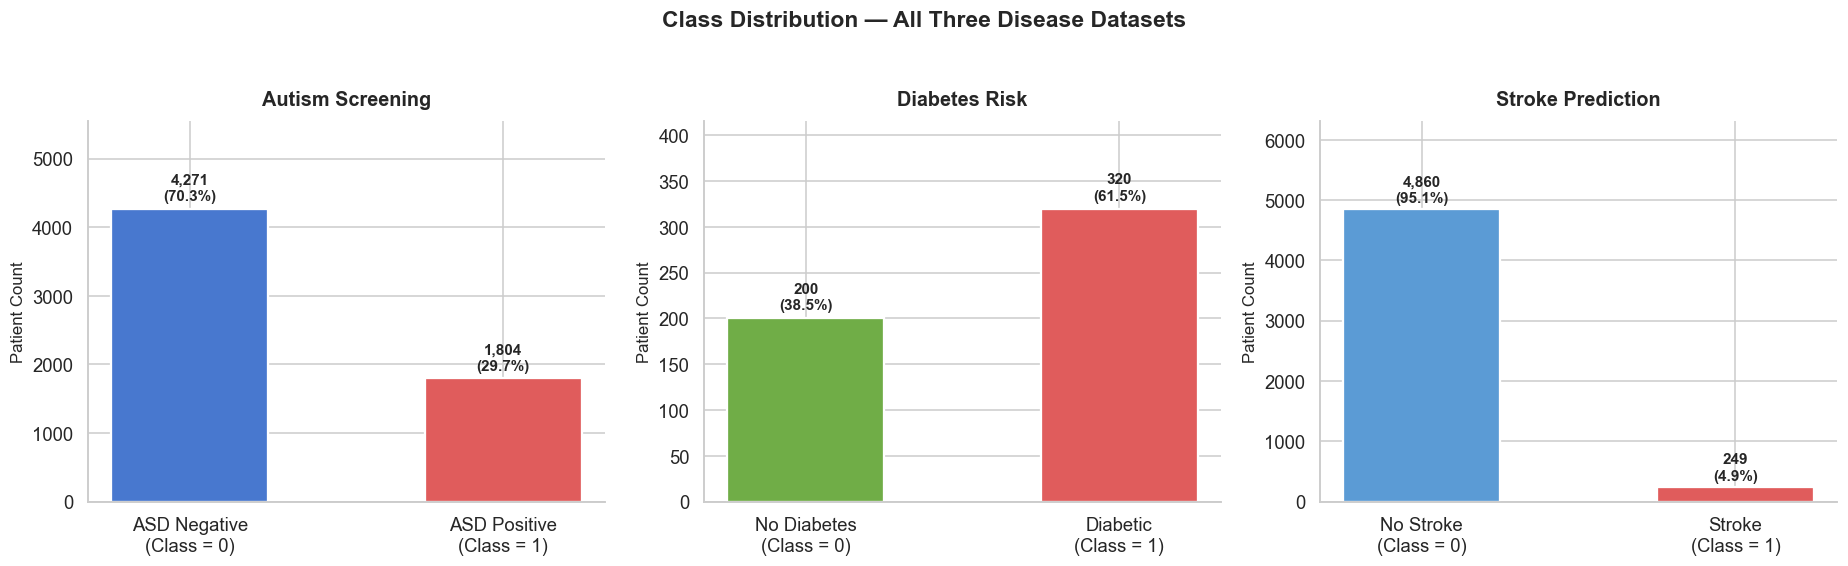

  [SAVED] reports/figures/01_class_distributions.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Class Distribution — All Three Disease Datasets',
             fontsize=15, fontweight='bold', y=1.03)

configs = [
    (df_a, 'Autism Screening',
     ['ASD Negative\n(Class = 0)', 'ASD Positive\n(Class = 1)'],
     ['#4878CF', '#E05C5C']),
    (df_d, 'Diabetes Risk',
     ['No Diabetes\n(Class = 0)', 'Diabetic\n(Class = 1)'],
     ['#70AD47', '#E05C5C']),
    (df_s, 'Stroke Prediction',
     ['No Stroke\n(Class = 0)', 'Stroke\n(Class = 1)'],
     ['#5B9BD5', '#E05C5C']),
]

for ax, (df, title, xlabels, colors) in zip(axes, configs):
    counts = df['Class'].value_counts().sort_index()
    bars   = ax.bar(xlabels, counts.values, color=colors,
                    edgecolor='white', linewidth=1.5, width=0.5)
    for bar in bars:
        h   = bar.get_height()
        pct = h / len(df) * 100
        ax.text(bar.get_x() + bar.get_width() / 2.,
                h + len(df) * 0.012,
                f'{h:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, pad=10)
    ax.set_ylabel('Patient Count')
    ax.set_ylim(0, counts.max() * 1.30)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
savefig('01_class_distributions.png')

In [4]:
imbalance_df = pd.DataFrame({
    'Dataset'         : ['Autism Screening', 'Diabetes Risk', 'Stroke Prediction'],
    'Total Patients'  : [len(df_a),          len(df_d),       len(df_s)],
    'Positive (1)'    : [(df_a['Class']==1).sum(),
                         (df_d['Class']==1).sum(),
                         (df_s['Class']==1).sum()],
    'Negative (0)'    : [(df_a['Class']==0).sum(),
                         (df_d['Class']==0).sum(),
                         (df_s['Class']==0).sum()],
    'Positive %'      : [f"{(df_a['Class']==1).mean()*100:.1f}%",
                         f"{(df_d['Class']==1).mean()*100:.1f}%",
                         f"{(df_s['Class']==1).mean()*100:.2f}%"],
    'Imbalance Ratio' : [
        f"1 : {(df_a['Class']==0).sum() / (df_a['Class']==1).sum():.1f}",
        f"1 : {(df_d['Class']==0).sum() / (df_d['Class']==1).sum():.1f}",
        f"1 : {(df_s['Class']==0).sum() / (df_s['Class']==1).sum():.1f}",
    ],
    'Strategy'        : [
        'class_weight=balanced',
        'class_weight=balanced',
        'SMOTE + scale_pos_weight (SEVERE)',
    ],
}).set_index('Dataset')

imbalance_df

,Total Patients,Positive (1),Negative (0),Positive %,Imbalance Ratio,Strategy
Dataset,,,,,,
Autism Screening,6075,1804,4271,29.7%,1 : 2.4,class_weight=balanced
Diabetes Risk,520,320,200,61.5%,1 : 0.6,class_weight=balanced
Stroke Prediction,5109,249,4860,4.87%,1 : 19.5,SMOTE + scale_pos_weight (SEVERE)


---
## 2 · Autism Screening — EDA

**Key features:** AQ-10 behavioural questionnaire items (A1–A10), Age (months),
Sex, Jaundice history, Family ASD history, and the derived **AQ Score** (sum A1–A10).

**Clinical context:** The AQ-10 clinical referral threshold is AQ ≥ 6.
Patients scoring above this are typically referred for full diagnostic assessment.

**Imbalance:** 29.7 % positive — mild. Class weights will suffice.

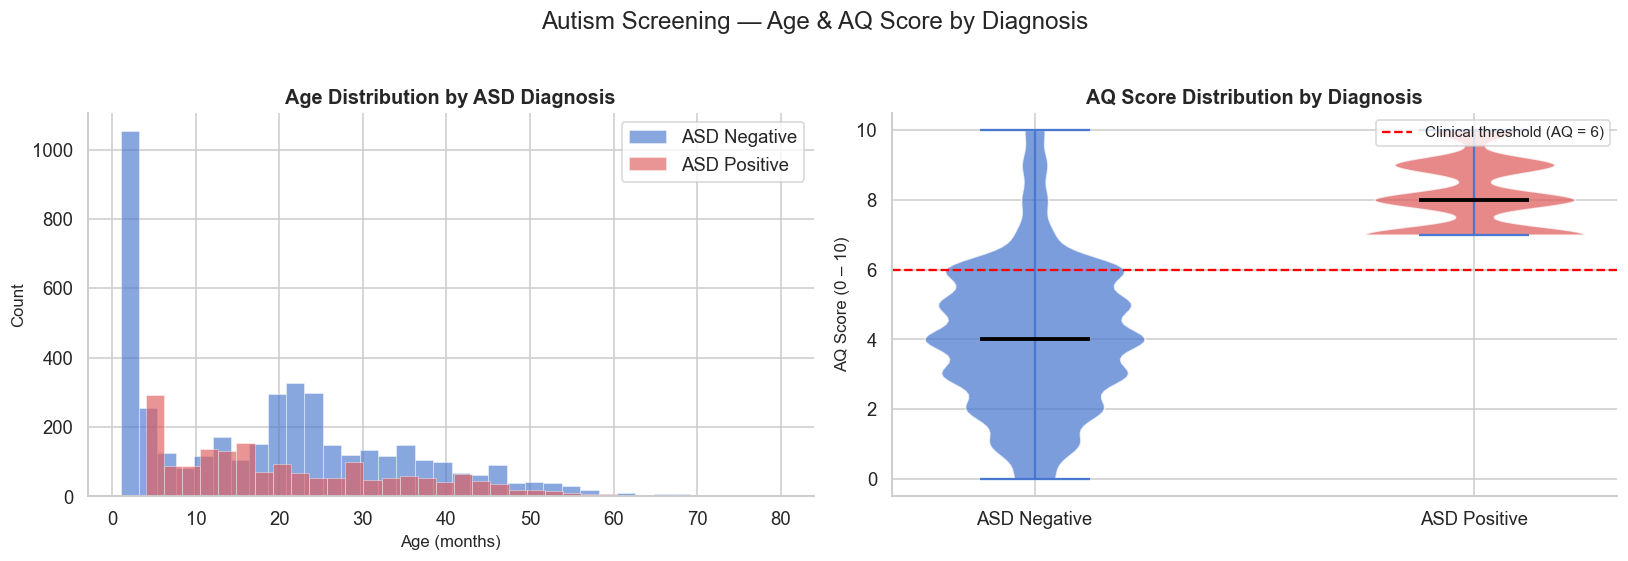

  [SAVED] reports/figures/02_autism_age_aqscore.png

AQ Score — Descriptive Statistics by Class:
           count  mean   std  min  25%  50%  75%   max
Class                                                 
Negative  4271.0  4.11  2.12  0.0  3.0  4.0  6.0  10.0
Positive  1804.0  8.16  1.02  7.0  7.0  8.0  9.0  10.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Autism Screening — Age & AQ Score by Diagnosis', y=1.02)

label_map = {0: 'ASD Negative', 1: 'ASD Positive'}
colors    = {0: '#4878CF',      1: '#E05C5C'}

# Left — Age histogram
for lbl, grp in df_a.groupby('Class'):
    axes[0].hist(grp['Age'], bins=35, alpha=0.65,
                 label=label_map[lbl], color=colors[lbl],
                 edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Age (months)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by ASD Diagnosis')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Right — AQ Score violin
grp0 = df_a[df_a['Class'] == 0]['AQ_Score']
grp1 = df_a[df_a['Class'] == 1]['AQ_Score']
parts = axes[1].violinplot([grp0, grp1], positions=[0, 1],
                           showmedians=True, showextrema=True)
body_colors = ['#4878CF', '#E05C5C']
for i, body in enumerate(parts['bodies']):
    body.set_facecolor(body_colors[i])
    body.set_alpha(0.72)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2.5)

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['ASD Negative', 'ASD Positive'])
axes[1].set_ylabel('AQ Score (0 – 10)')
axes[1].set_title('AQ Score Distribution by Diagnosis')
axes[1].axhline(6, color='red', linestyle='--', linewidth=1.5,
                label='Clinical threshold (AQ = 6)')
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
savefig('02_autism_age_aqscore.png')

print('\nAQ Score — Descriptive Statistics by Class:')
print(df_a.groupby('Class')['AQ_Score']
        .describe().rename(index={0:'Negative',1:'Positive'}).round(2))

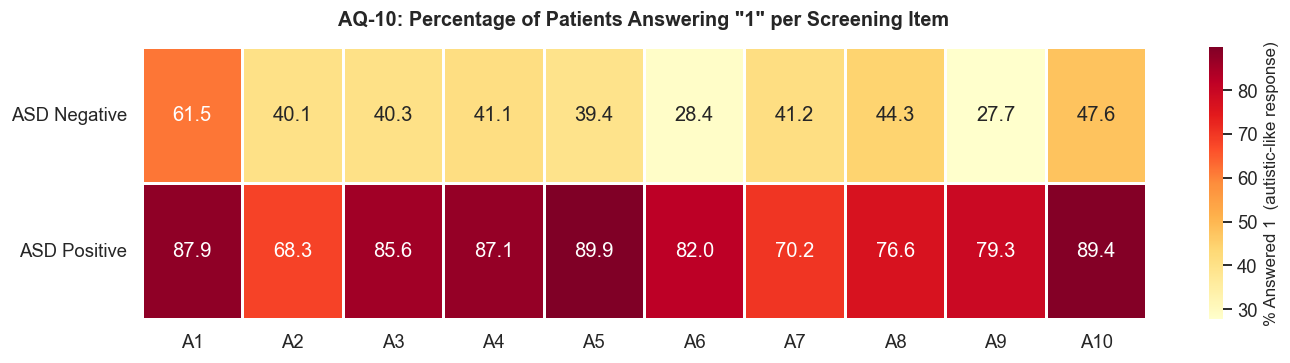

  [SAVED] reports/figures/03_autism_aq10_item_heatmap.png

Interpretation:
  Items where ASD-Positive >> ASD-Negative are the most discriminating.
  A6: +53.6 pp higher in ASD-Positive group
  A9: +51.6 pp higher in ASD-Positive group
  A5: +50.5 pp higher in ASD-Positive group


In [6]:
aq_cols = [f'A{i}' for i in range(1, 11)]

# % of patients who answered 1 on each item, split by class
rates = pd.DataFrame({
    'ASD Negative': df_a[df_a['Class'] == 0][aq_cols].mean() * 100,
    'ASD Positive': df_a[df_a['Class'] == 1][aq_cols].mean() * 100,
}).T

fig, ax = plt.subplots(figsize=(13, 3.5))
sns.heatmap(rates, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.8, linecolor='white', ax=ax,
            cbar_kws={'label': '% Answered 1  (autistic-like response)'})
ax.set_title(
    'AQ-10: Percentage of Patients Answering "1" per Screening Item',
    pad=14)
ax.set_ylabel('')
ax.tick_params(axis='x', labelrotation=0)
ax.tick_params(axis='y', labelrotation=0)
plt.tight_layout()
savefig('03_autism_aq10_item_heatmap.png')

print('\nInterpretation:')
print('  Items where ASD-Positive >> ASD-Negative are the most discriminating.')
diff = rates.loc['ASD Positive'] - rates.loc['ASD Negative']
top3 = diff.nlargest(3)
for item, gap in top3.items():
    print(f'  {item}: +{gap:.1f} pp higher in ASD-Positive group')

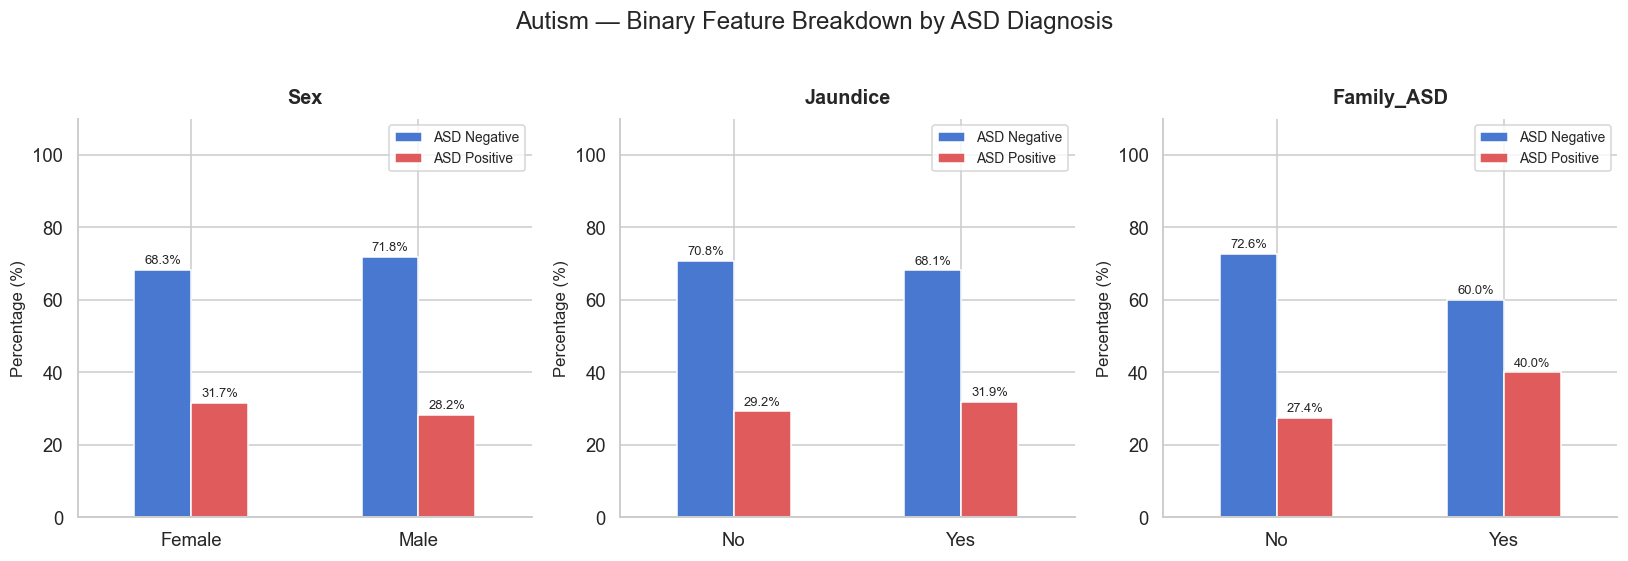

  [SAVED] reports/figures/04_autism_binary_features.png


In [7]:
binary_feats = {'Sex': {0:'Female', 1:'Male'},
                'Jaundice': {0:'No', 1:'Yes'},
                'Family_ASD': {0:'No', 1:'Yes'}}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Autism — Binary Feature Breakdown by ASD Diagnosis', y=1.02)

for ax, (feat, val_map) in zip(axes, binary_feats.items()):
    ct = pd.crosstab(df_a[feat], df_a['Class'],
                     rownames=[feat], colnames=['Class'])
    ct.index = [val_map[i] for i in ct.index]
    ct.columns = ['ASD Negative', 'ASD Positive']
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=['#4878CF', '#E05C5C'],
                edgecolor='white', rot=0)
    ax.set_title(f'{feat}', pad=10)
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, 110)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=8.5, padding=2)

plt.tight_layout()
savefig('04_autism_binary_features.png')

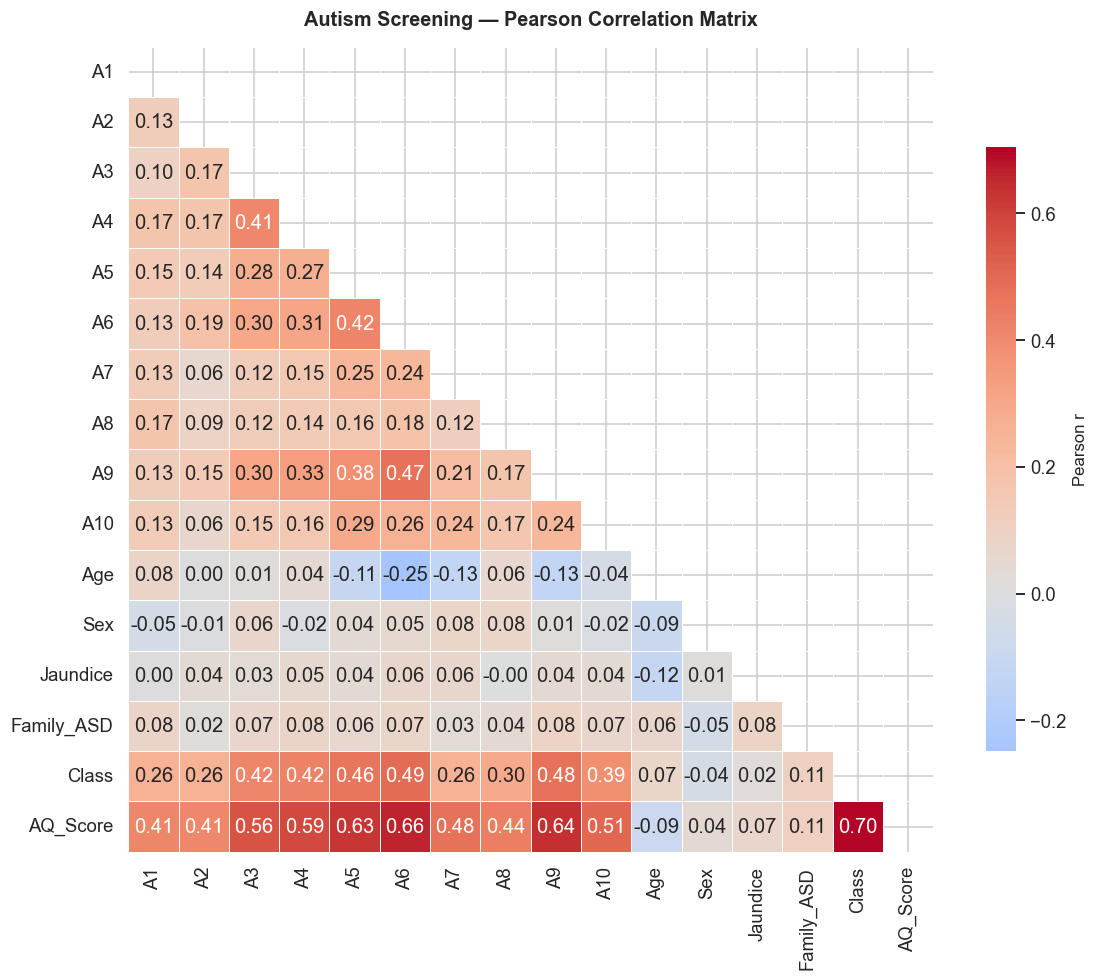

  [SAVED] reports/figures/05_autism_correlation_heatmap.png

Top correlations with target (Class):
AQ_Score    0.704
A6          0.493
A9          0.476
A5          0.463
A4          0.423
A3          0.416
A10         0.390
A8          0.296


In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
corr_a  = df_a.corr(numeric_only=True)
mask_a  = np.triu(np.ones_like(corr_a, dtype=bool))

sns.heatmap(corr_a, mask=mask_a, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
ax.set_title('Autism Screening — Pearson Correlation Matrix', pad=14)
plt.tight_layout()
savefig('05_autism_correlation_heatmap.png')

print('\nTop correlations with target (Class):')
corr_with_target = (corr_a['Class']
                    .drop('Class')
                    .abs()
                    .sort_values(ascending=False))
print(corr_with_target.head(8).round(3).to_string())

---
## 3 · Diabetes Risk — EDA

**Key features:** Age, Gender, and 14 binary clinical symptoms.

**Important caveat:** With only 520 rows this is a **small dataset**.
- Risk of overfitting is high → use 10-fold stratified CV
- Avoid very deep models (XGBoost with shallow max_depth is safer)
- Report MCC alongside F1 to account for the mild imbalance

**Imbalance:** 61.5 % positive — mild. Class weights sufficient.

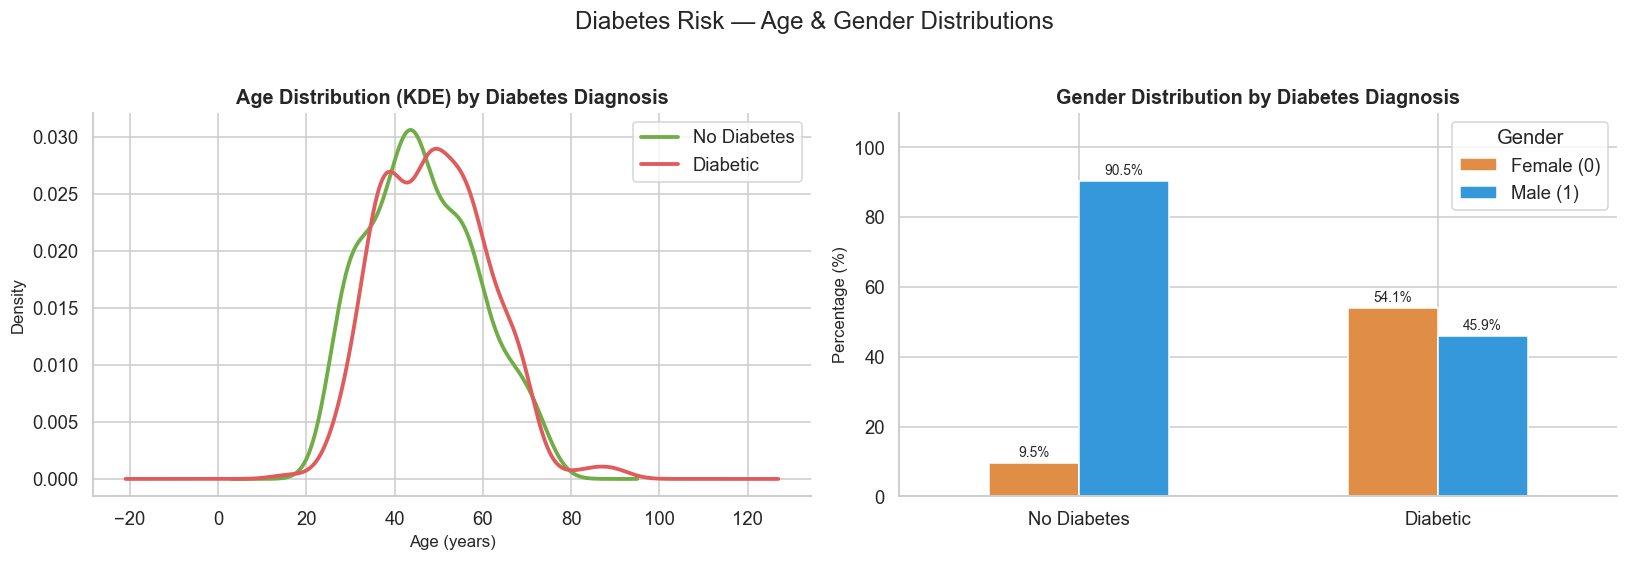

  [SAVED] reports/figures/06_diabetes_age_gender.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Diabetes Risk — Age & Gender Distributions', y=1.02)

# Left — Age KDE by class
for lbl, grp in df_d.groupby('Class'):
    name  = 'Diabetic' if lbl == 1 else 'No Diabetes'
    color = '#E05C5C'  if lbl == 1 else '#70AD47'
    grp['Age'].plot.kde(ax=axes[0], label=name,
                        linewidth=2.5, color=color)
axes[0].set_xlabel('Age (years)')
axes[0].set_title('Age Distribution (KDE) by Diabetes Diagnosis')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Right — Gender stacked proportional bar
gd = (df_d.groupby(['Class', 'Gender'])
          .size()
          .unstack(fill_value=0))
gd.columns = ['Female (0)', 'Male (1)']
gd.index   = ['No Diabetes', 'Diabetic']
gd_pct     = gd.div(gd.sum(axis=1), axis=0) * 100
gd_pct.plot(kind='bar', ax=axes[1],
            color=['#E08E45', '#3498DB'], edgecolor='white', rot=0)
axes[1].set_title('Gender Distribution by Diabetes Diagnosis')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(0, 110)
axes[1].legend(title='Gender')
axes[1].spines[['top', 'right']].set_visible(False)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9, padding=2)

plt.tight_layout()
savefig('06_diabetes_age_gender.png')

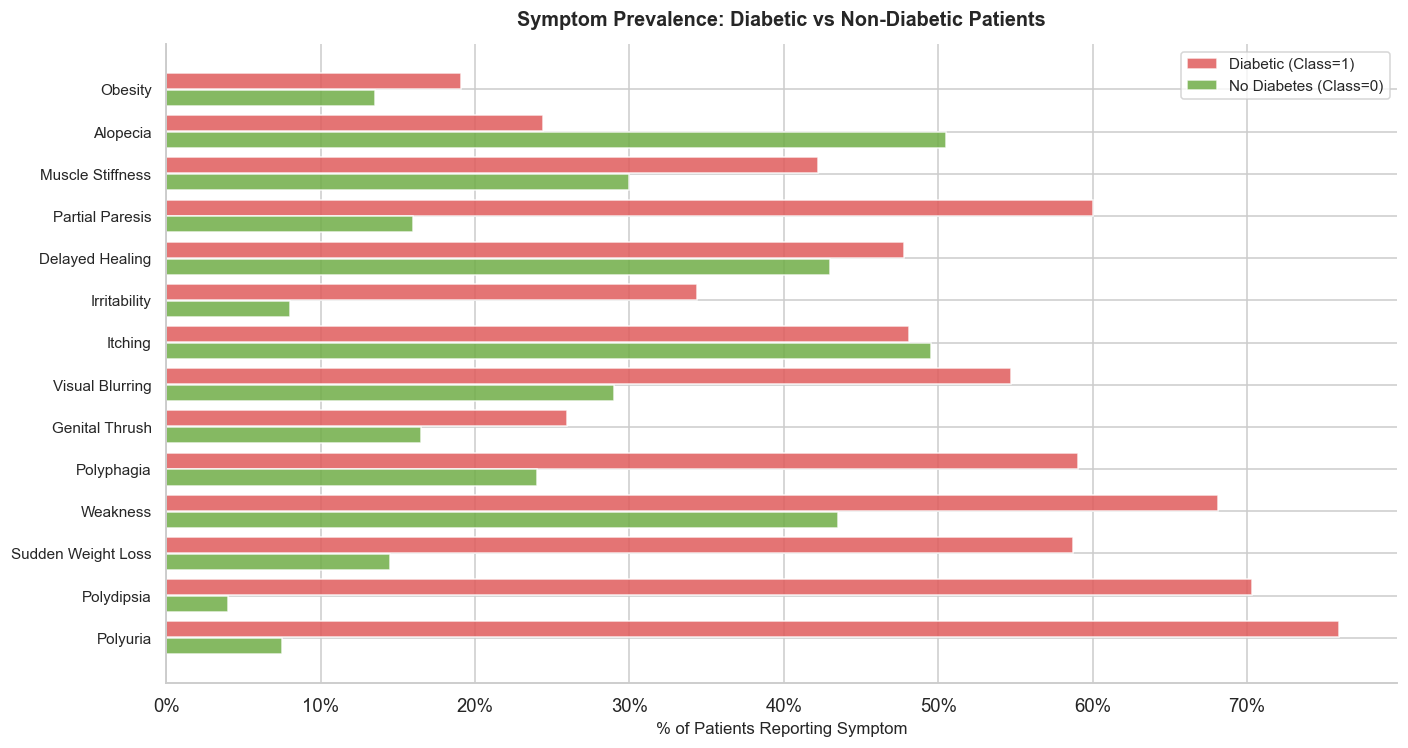

  [SAVED] reports/figures/07_diabetes_symptom_prevalence.png

Top 5 discriminating symptoms (gap between classes):
  Polyuria                   +68.4 pp in diabetic group
  Polydipsia                 +66.3 pp in diabetic group
  Sudden Weight Loss         +44.2 pp in diabetic group
  Partial Paresis            +44.0 pp in diabetic group
  Polyphagia                 +35.1 pp in diabetic group


In [10]:
symptom_cols = [
    'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
    'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
    'Irritability', 'delayed healing', 'partial paresis',
    'muscle stiffness', 'Alopecia', 'Obesity',
]
pretty = {
    'sudden weight loss': 'Sudden Weight Loss',
    'Genital thrush'    : 'Genital Thrush',
    'visual blurring'   : 'Visual Blurring',
    'delayed healing'   : 'Delayed Healing',
    'partial paresis'   : 'Partial Paresis',
    'muscle stiffness'  : 'Muscle Stiffness',
}
labels    = [pretty.get(c, c.title()) for c in symptom_cols]
pos_rates = df_d[df_d['Class'] == 1][symptom_cols].mean() * 100
neg_rates = df_d[df_d['Class'] == 0][symptom_cols].mean() * 100

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(x + 0.2,  pos_rates.values, height=0.38,
        color='#E05C5C', label='Diabetic (Class=1)', alpha=0.85)
ax.barh(x - 0.2,  neg_rates.values, height=0.38,
        color='#70AD47', label='No Diabetes (Class=0)', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('% of Patients Reporting Symptom')
ax.set_title('Symptom Prevalence: Diabetic vs Non-Diabetic Patients', pad=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
savefig('07_diabetes_symptom_prevalence.png')

print('\nTop 5 discriminating symptoms (gap between classes):')
gap = (pos_rates - neg_rates).sort_values(ascending=False)
for feat, val in gap.head(5).items():
    print(f'  {pretty.get(feat, feat):<25}  +{val:.1f} pp in diabetic group')

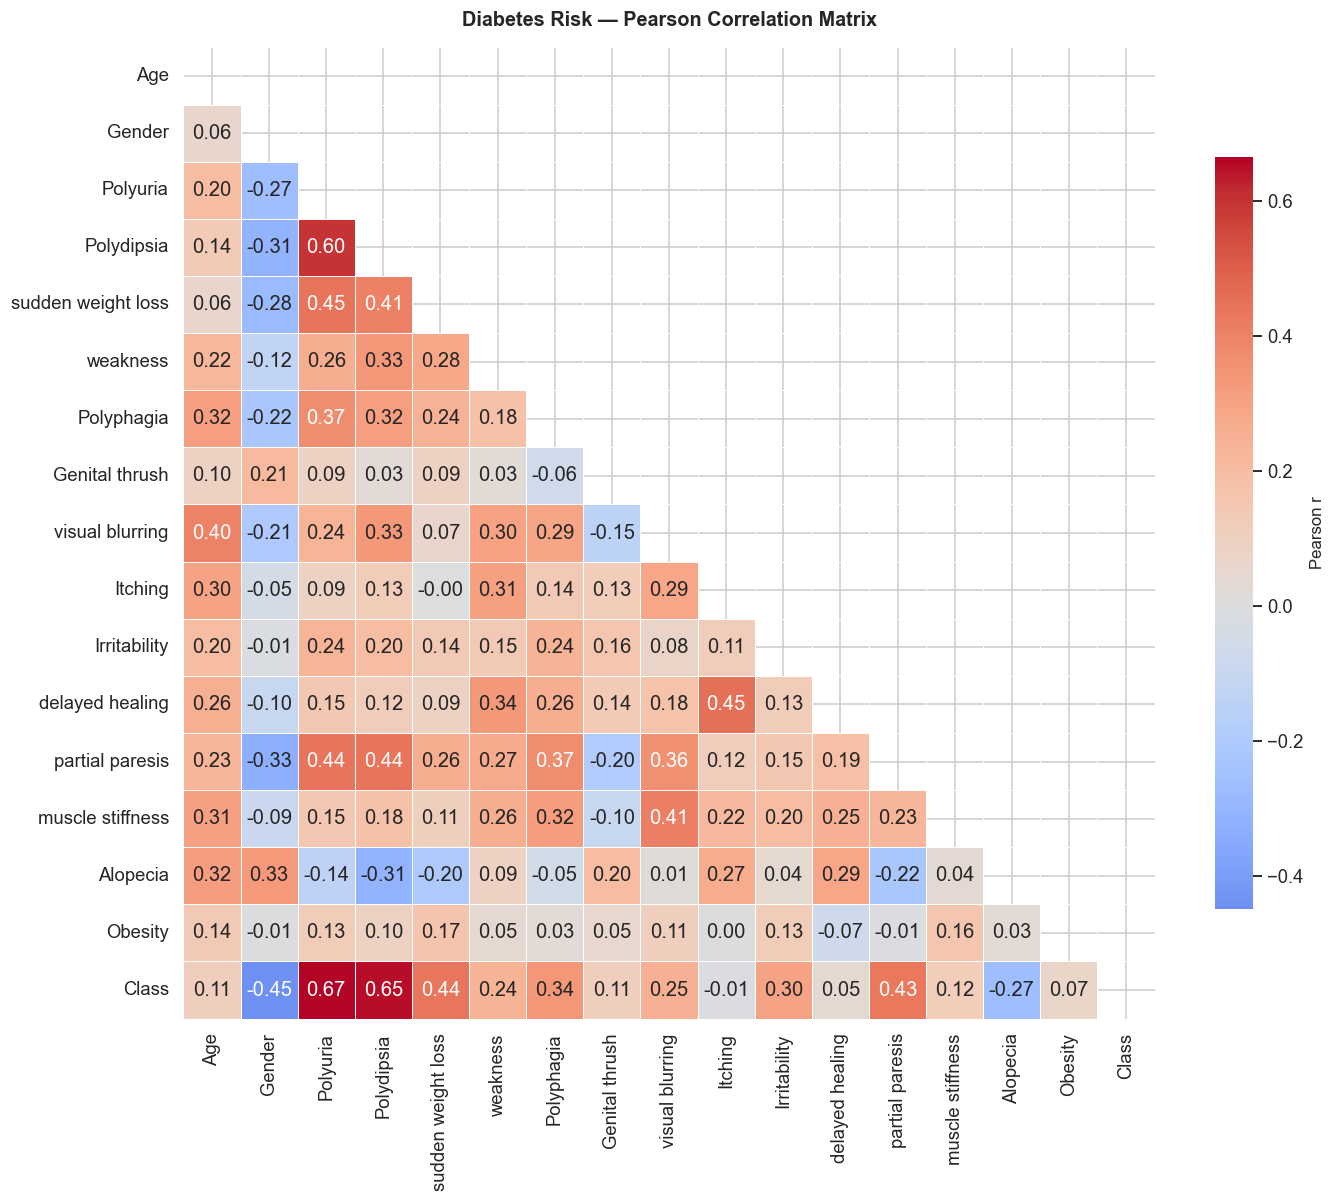

  [SAVED] reports/figures/08_diabetes_correlation_heatmap.png

Top correlations with target (Class):
Polyuria              0.666
Polydipsia            0.649
Gender                0.449
sudden weight loss    0.437
partial paresis       0.432
Polyphagia            0.343
Irritability          0.299
Alopecia              0.268


In [11]:
fig, ax = plt.subplots(figsize=(13, 11))
corr_d  = df_d.corr(numeric_only=True)
mask_d  = np.triu(np.ones_like(corr_d, dtype=bool))

sns.heatmap(corr_d, mask=mask_d, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
ax.set_title('Diabetes Risk — Pearson Correlation Matrix', pad=14)
plt.tight_layout()
savefig('08_diabetes_correlation_heatmap.png')

print('\nTop correlations with target (Class):')
print((corr_d['Class'].drop('Class')
                      .abs()
                      .sort_values(ascending=False)
                      .head(8).round(3).to_string()))

---
## 4 · Stroke Prediction — EDA

**Key continuous features:** Age, Avg Glucose Level, BMI
**Key binary features:** Hypertension, Heart Disease, Ever Married, Residence Type
**Categorical features:** Work Type (5 categories), Smoking Status (4 categories)

**Critical clinical note:**
> A **False Negative** (missed stroke) has far greater clinical cost than a
> False Positive (unnecessary investigation). We therefore **prioritise Recall**
> over Precision when choosing the decision threshold.

**Severe imbalance (19.5 : 1):** SMOTE on training folds + `scale_pos_weight` mandatory.

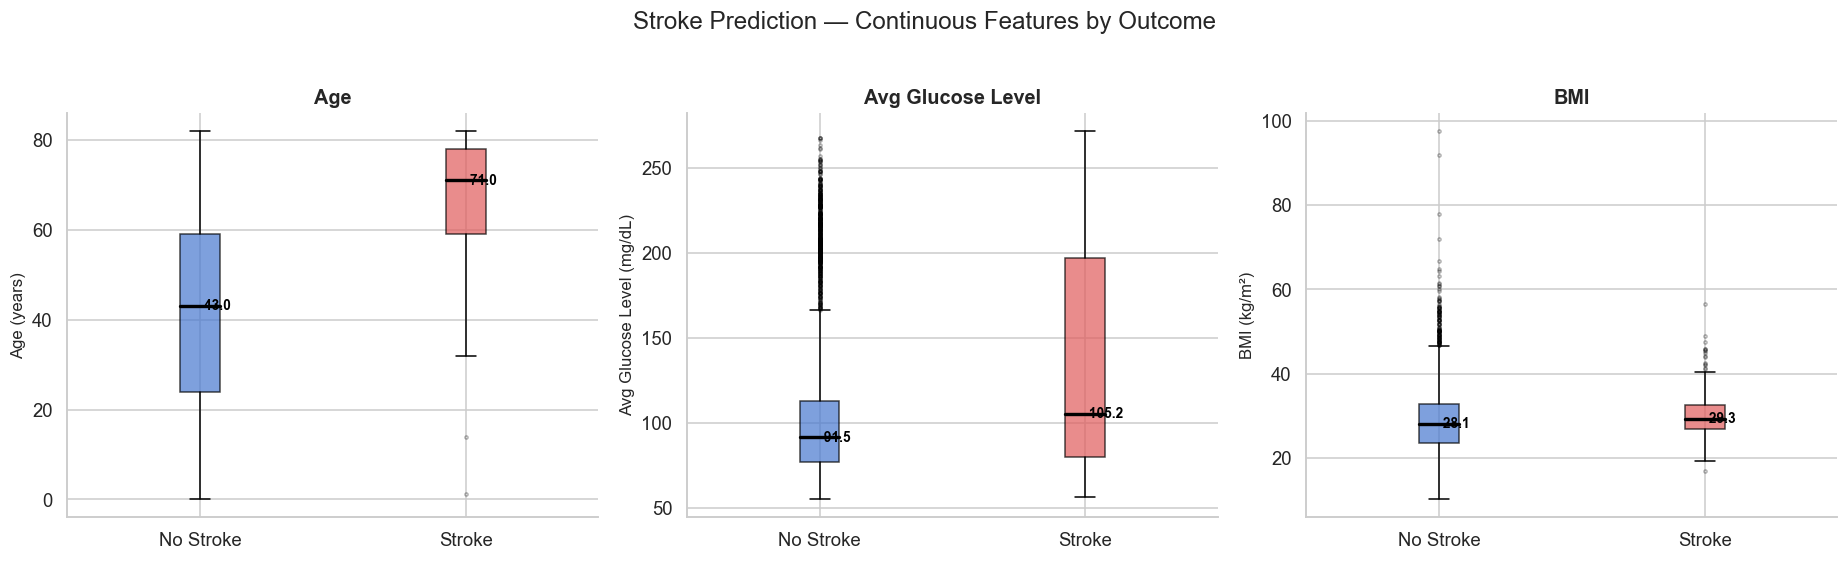

  [SAVED] reports/figures/09_stroke_continuous_boxplots.png

Descriptive stats — continuous features by stroke outcome:

  Age (years):
            mean   50%    std
Class                        
No Stroke  41.97  43.0  22.29
Stroke     67.73  71.0  12.73

  Avg Glucose Level (mg/dL):
             mean     50%    std
Class                           
No Stroke  104.79   91.46  43.85
Stroke     132.54  105.22  61.92

  BMI (kg/m²):
            mean   50%   std
Class                       
No Stroke  28.80  28.1  7.80
Stroke     30.27  29.3  5.85


In [12]:
cont_feats = [
    ('age',               'Age (years)'),
    ('avg_glucose_level', 'Avg Glucose Level (mg/dL)'),
    ('bmi',               'BMI (kg/m²)'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Stroke Prediction — Continuous Features by Outcome', y=1.02)

for ax, (col, ylabel) in zip(axes, cont_feats):
    data     = [df_s[df_s['Class'] == 0][col],
                df_s[df_s['Class'] == 1][col]]
    bp = ax.boxplot(data, labels=['No Stroke', 'Stroke'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2.2),
                    flierprops=dict(marker='o', markersize=2,
                                    alpha=0.3, color='grey'))
    bp['boxes'][0].set_facecolor('#4878CF'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#E05C5C'); bp['boxes'][1].set_alpha(0.7)
    ax.set_title(ylabel.split(' (')[0])
    ax.set_ylabel(ylabel)
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate medians
    for i, d in enumerate(data):
        med = d.median()
        ax.text(i + 1, med, f' {med:.1f}', va='center',
                fontsize=9, color='black', fontweight='bold')

plt.tight_layout()
savefig('09_stroke_continuous_boxplots.png')

print('\nDescriptive stats — continuous features by stroke outcome:')
for col, label in cont_feats:
    print(f'\n  {label}:')
    print(df_s.groupby('Class')[col]
              .describe()[['mean','50%','std']]
              .rename(index={0:'No Stroke',1:'Stroke'}).round(2))

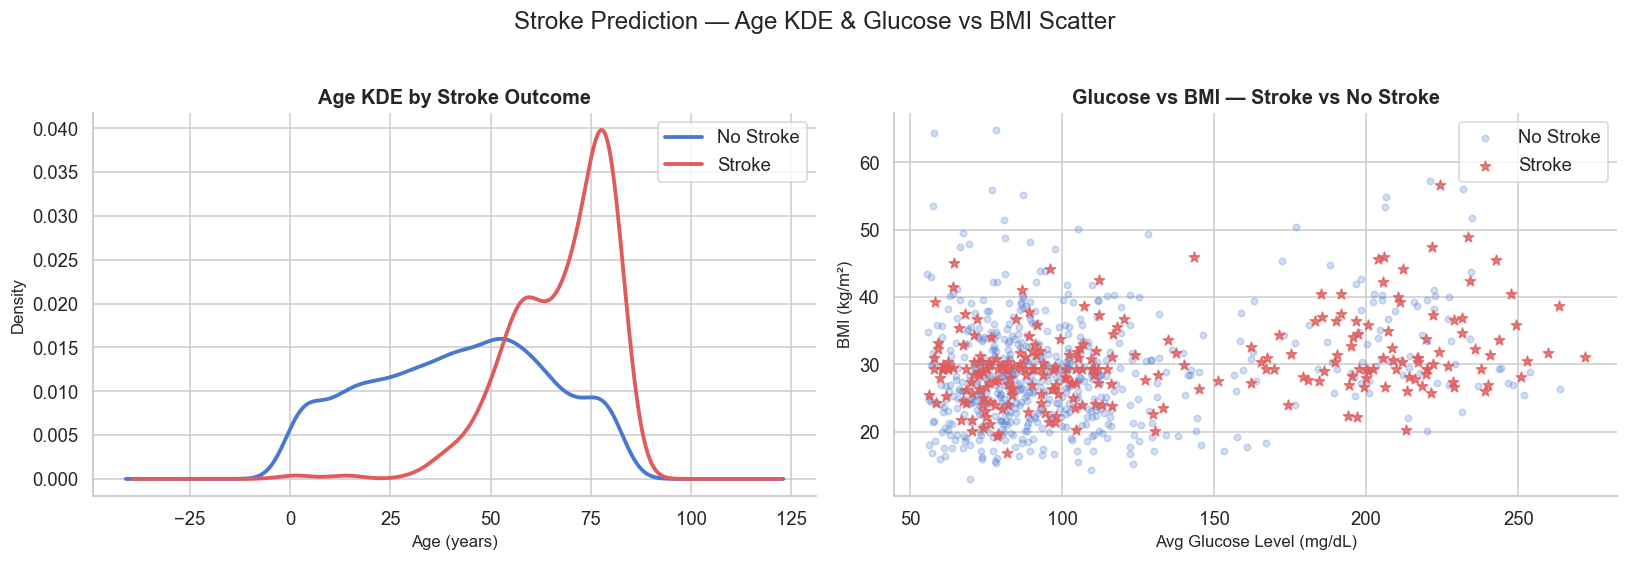

  [SAVED] reports/figures/10_stroke_kde_scatter.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Stroke Prediction — Age KDE & Glucose vs BMI Scatter', y=1.02)

# Left — Age KDE
for lbl, grp in df_s.groupby('Class'):
    name  = 'Stroke'    if lbl == 1 else 'No Stroke'
    color = '#E05C5C'   if lbl == 1 else '#4878CF'
    grp['age'].plot.kde(ax=axes[0], label=name,
                        linewidth=2.5, color=color)
axes[0].set_xlabel('Age (years)')
axes[0].set_title('Age KDE by Stroke Outcome')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Right — Glucose vs BMI scatter
no_s = df_s[df_s['Class'] == 0].sample(600, random_state=42)
yess = df_s[df_s['Class'] == 1]
axes[1].scatter(no_s['avg_glucose_level'], no_s['bmi'],
                alpha=0.25, color='#4878CF', s=18, label='No Stroke')
axes[1].scatter(yess['avg_glucose_level'], yess['bmi'],
                alpha=0.80, color='#E05C5C', s=50,
                marker='*', label='Stroke', zorder=5)
axes[1].set_xlabel('Avg Glucose Level (mg/dL)')
axes[1].set_ylabel('BMI (kg/m²)')
axes[1].set_title('Glucose vs BMI — Stroke vs No Stroke')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
savefig('10_stroke_kde_scatter.png')

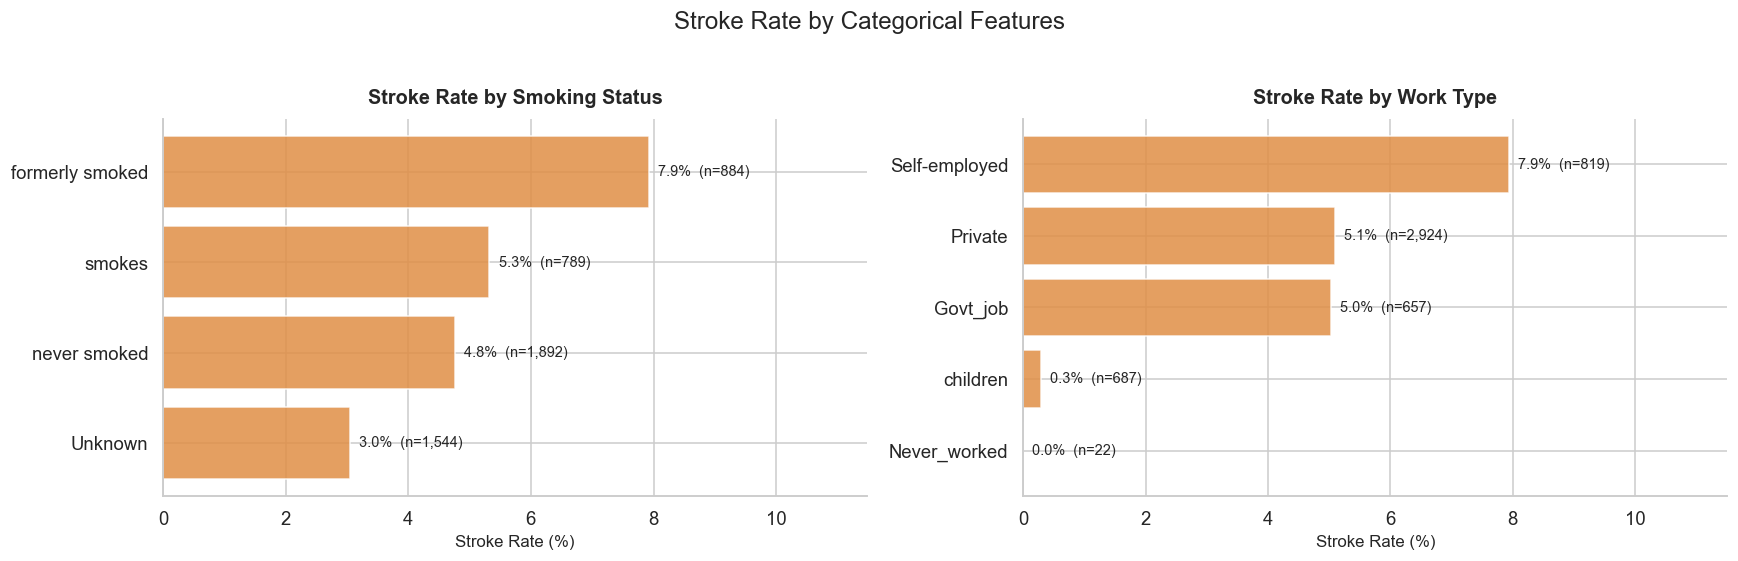

  [SAVED] reports/figures/11_stroke_categorical_breakdown.png


In [14]:
def stroke_rate_bar(ax, df, col, title):
    grp = (df.groupby(col)['Class']
             .agg(['sum', 'count'])
             .assign(rate=lambda x: x['sum'] / x['count'] * 100)
             .sort_values('rate', ascending=True))
    bars = ax.barh(grp.index, grp['rate'],
                   color='#E08E45', edgecolor='white', alpha=0.85)
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(row['rate'] + 0.15, bar.get_y() + bar.get_height()/2,
                f"{row['rate']:.1f}%  (n={int(row['count']):,})",
                va='center', fontsize=9.5)
    ax.set_xlabel('Stroke Rate (%)')
    ax.set_title(title, pad=10)
    ax.set_xlim(0, grp['rate'].max() * 1.45)
    ax.spines[['top', 'right']].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Stroke Rate by Categorical Features', y=1.02)

stroke_rate_bar(axes[0], df_s, 'smoking_status', 'Stroke Rate by Smoking Status')
stroke_rate_bar(axes[1], df_s, 'work_type',      'Stroke Rate by Work Type')

plt.tight_layout()
savefig('11_stroke_categorical_breakdown.png')

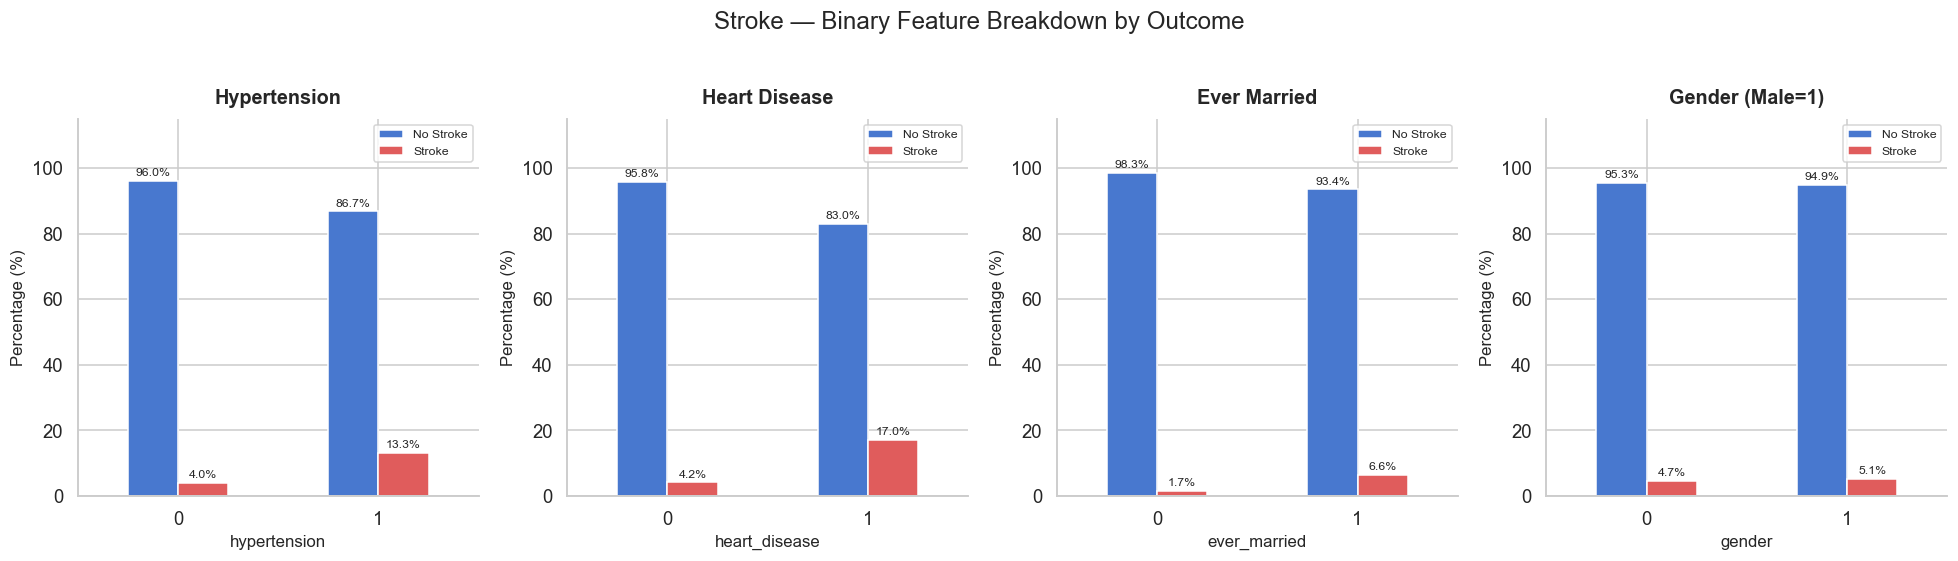

  [SAVED] reports/figures/12_stroke_binary_features.png


In [15]:
binary_feats_s = {
    'hypertension' : 'Hypertension',
    'heart_disease': 'Heart Disease',
    'ever_married' : 'Ever Married',
    'gender'       : 'Gender (Male=1)',
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Stroke — Binary Feature Breakdown by Outcome', y=1.02)

for ax, (col, title) in zip(axes, binary_feats_s.items()):
    ct     = pd.crosstab(df_s[col], df_s['Class'])
    ct.columns = ['No Stroke', 'Stroke']
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax,
                color=['#4878CF', '#E05C5C'],
                edgecolor='white', rot=0)
    ax.set_title(title, pad=10)
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, 115)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)

plt.tight_layout()
savefig('12_stroke_binary_features.png')

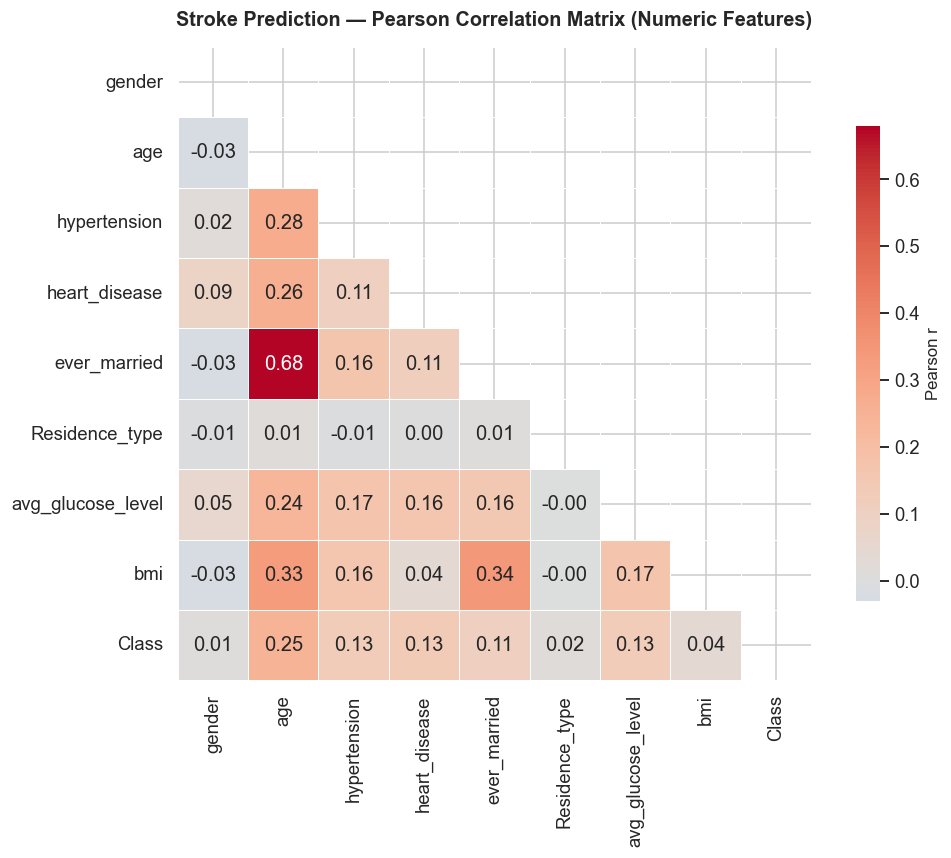

  [SAVED] reports/figures/13_stroke_correlation_heatmap.png

Top correlations with stroke label (Class):
age                  0.245
heart_disease        0.135
avg_glucose_level    0.132
hypertension         0.128
ever_married         0.108
bmi                  0.041
Residence_type       0.015
gender               0.009


In [16]:
df_s_num = df_s.drop(columns=['work_type', 'smoking_status'])
corr_s   = df_s_num.corr(numeric_only=True)
mask_s   = np.triu(np.ones_like(corr_s, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_s, mask=mask_s, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
ax.set_title('Stroke Prediction — Pearson Correlation Matrix (Numeric Features)',
             pad=14)
plt.tight_layout()
savefig('13_stroke_correlation_heatmap.png')

print('\nTop correlations with stroke label (Class):')
print((corr_s['Class'].drop('Class')
                      .abs()
                      .sort_values(ascending=False)
                      .head(8).round(3).to_string()))

---
## 5 · Statistical Tests

### Methodology

| Test | Used For | Null Hypothesis (H₀) |
|---|---|---|
| **Chi-Square (χ²)** | Binary feature vs binary target | Feature and target are independent |
| **Mann-Whitney U** | Continuous feature vs binary target | Distributions are identical across classes |

**Why Mann-Whitney over t-test?**
Medical variables (BMI, glucose) are often skewed and non-normal.
Mann-Whitney U is non-parametric — it makes no normality assumption.

**Significance level:** α = 0.05. We reject H₀ when **p < 0.05**.

In [17]:
def chi2_test(df, feature, target='Class', alpha=0.05):
    ct           = pd.crosstab(df[feature], df[target])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig  = '✔  SIGNIFICANT' if p < alpha else '✘  not significant'
    return {
        'Feature'  : feature,
        'Chi²'     : round(chi2, 3),
        'p-value'  : round(p, 6),
        'DOF'      : dof,
        'Result'   : sig,
    }

# Autism
print('━━━  Chi-Square Tests: AUTISM  ━━━')
r_a = pd.DataFrame([chi2_test(df_a, c)
                    for c in ['Sex', 'Jaundice', 'Family_ASD']])
print(r_a.to_string(index=False))

# Diabetes
print('\n━━━  Chi-Square Tests: DIABETES  ━━━')
d_symp = ['Polyuria', 'Polydipsia', 'weakness', 'Polyphagia',
          'Itching', 'Irritability', 'partial paresis']
r_d = pd.DataFrame([chi2_test(df_d, c) for c in d_symp])
print(r_d.to_string(index=False))

# Stroke
print('\n━━━  Chi-Square Tests: STROKE  ━━━')
s_binary = ['hypertension', 'heart_disease', 'ever_married',
            'gender', 'Residence_type']
r_s = pd.DataFrame([chi2_test(df_s, c) for c in s_binary])
print(r_s.to_string(index=False))

━━━  Chi-Square Tests: AUTISM  ━━━
   Feature   Chi²  p-value  DOF             Result
       Sex  8.477 0.003598    1     ✔  SIGNIFICANT
  Jaundice  2.724 0.098852    1 ✘  not significant
Family_ASD 69.630 0.000000    1     ✔  SIGNIFICANT

━━━  Chi-Square Tests: DIABETES  ━━━


        Feature    Chi²  p-value  DOF             Result
       Polyuria 227.866 0.000000    1     ✔  SIGNIFICANT
     Polydipsia 216.172 0.000000    1     ✔  SIGNIFICANT
       weakness  29.768 0.000000    1     ✔  SIGNIFICANT
     Polyphagia  59.595 0.000000    1     ✔  SIGNIFICANT
        Itching   0.046 0.829748    1 ✘  not significant
   Irritability  45.208 0.000000    1     ✔  SIGNIFICANT
partial paresis  95.388 0.000000    1     ✔  SIGNIFICANT

━━━  Chi-Square Tests: STROKE  ━━━


       Feature   Chi²  p-value  DOF             Result
  hypertension 81.573 0.000000    1     ✔  SIGNIFICANT
 heart_disease 90.229 0.000000    1     ✔  SIGNIFICANT
  ever_married 58.868 0.000000    1     ✔  SIGNIFICANT
        gender  0.340 0.559828    1 ✘  not significant
Residence_type  1.075 0.299825    1 ✘  not significant


In [18]:
def mw_test(df, feature, target='Class', alpha=0.05):
    g0          = df[df[target] == 0][feature].dropna()
    g1          = df[df[target] == 1][feature].dropna()
    u_stat, p   = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    effect_r    = 1 - (2 * u_stat) / (len(g0) * len(g1))   # rank-biserial r
    sig         = '✔  SIGNIFICANT' if p < alpha else '✘  not significant'
    return {
        'Feature'        : feature,
        'Mean (Class=0)' : round(g0.mean(), 2),
        'Mean (Class=1)' : round(g1.mean(), 2),
        'U-stat'         : round(u_stat, 1),
        'p-value'        : round(p, 6),
        'Effect r'       : round(effect_r, 3),
        'Result'         : sig,
    }

print('━━━  Mann-Whitney U: AUTISM  ━━━')
r_mw_a = pd.DataFrame([mw_test(df_a, c) for c in ['Age', 'AQ_Score']])
print(r_mw_a.to_string(index=False))

print('\n━━━  Mann-Whitney U: DIABETES  ━━━')
r_mw_d = pd.DataFrame([mw_test(df_d, 'Age')])
print(r_mw_d.to_string(index=False))

print('\n━━━  Mann-Whitney U: STROKE  ━━━')
r_mw_s = pd.DataFrame([mw_test(df_s, c)
                        for c in ['age', 'avg_glucose_level', 'bmi']])
print(r_mw_s.to_string(index=False))

print('\n  Effect size interpretation  |r|:')
print('    < 0.10  →  negligible')
print('    0.10 – 0.30  →  small')
print('    0.30 – 0.50  →  medium')
print('    > 0.50  →  large')

━━━  Mann-Whitney U: AUTISM  ━━━
 Feature  Mean (Class=0)  Mean (Class=1)    U-stat  p-value  Effect r         Result
     Age           19.13           21.50 3347069.0      0.0     0.131 ✔  SIGNIFICANT
AQ_Score            4.11            8.16  380579.0      0.0     0.901 ✔  SIGNIFICANT

━━━  Mann-Whitney U: DIABETES  ━━━
Feature  Mean (Class=0)  Mean (Class=1)  U-stat  p-value  Effect r         Result
    Age           46.36           49.07 27834.0 0.012404      0.13 ✔  SIGNIFICANT

━━━  Mann-Whitney U: STROKE  ━━━


          Feature  Mean (Class=0)  Mean (Class=1)   U-stat  p-value  Effect r         Result
              age           41.97           67.73 200261.5 0.000000     0.669 ✔  SIGNIFICANT
avg_glucose_level          104.79          132.54 471082.0 0.000000     0.221 ✔  SIGNIFICANT
              bmi           28.80           30.27 510239.0 0.000029     0.157 ✔  SIGNIFICANT

  Effect size interpretation  |r|:
    < 0.10  →  negligible
    0.10 – 0.30  →  small
    0.30 – 0.50  →  medium
    > 0.50  →  large


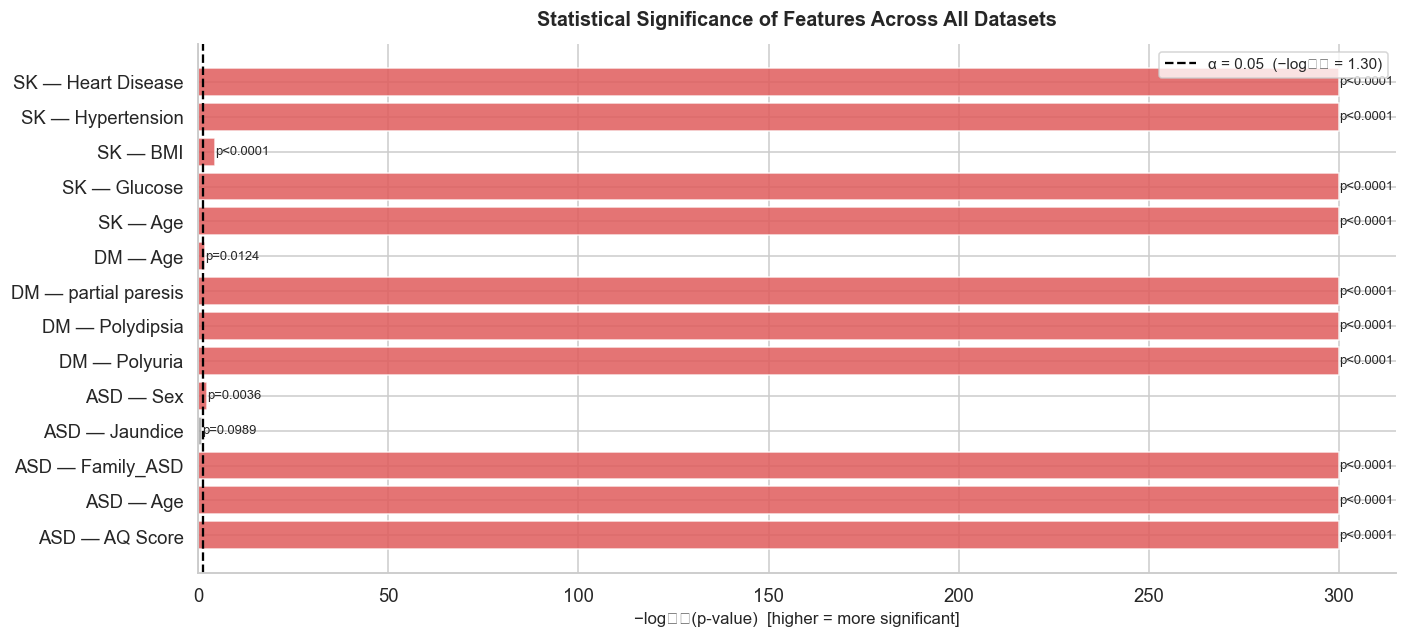

  [SAVED] reports/figures/14_statistical_significance.png


In [19]:
# Collect all p-values from both test types for a combined significance plot
all_tests = {
    # Autism
    'ASD — AQ Score'      : mw_test(df_a, 'AQ_Score')['p-value'],
    'ASD — Age'           : mw_test(df_a, 'Age')['p-value'],
    'ASD — Family_ASD'    : chi2_test(df_a, 'Family_ASD')['p-value'],
    'ASD — Jaundice'      : chi2_test(df_a, 'Jaundice')['p-value'],
    'ASD — Sex'           : chi2_test(df_a, 'Sex')['p-value'],
    # Diabetes
    'DM — Polyuria'       : chi2_test(df_d, 'Polyuria')['p-value'],
    'DM — Polydipsia'     : chi2_test(df_d, 'Polydipsia')['p-value'],
    'DM — partial paresis': chi2_test(df_d, 'partial paresis')['p-value'],
    'DM — Age'            : mw_test(df_d, 'Age')['p-value'],
    # Stroke
    'SK — Age'            : mw_test(df_s, 'age')['p-value'],
    'SK — Glucose'        : mw_test(df_s, 'avg_glucose_level')['p-value'],
    'SK — BMI'            : mw_test(df_s, 'bmi')['p-value'],
    'SK — Hypertension'   : chi2_test(df_s, 'hypertension')['p-value'],
    'SK — Heart Disease'  : chi2_test(df_s, 'heart_disease')['p-value'],
}

names  = list(all_tests.keys())
pvals  = list(all_tests.values())
colors = ['#E05C5C' if p < 0.05 else '#AAAAAA' for p in pvals]
neg_log_p = [-np.log10(max(p, 1e-300)) for p in pvals]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(names, neg_log_p, color=colors, edgecolor='white', alpha=0.85)
ax.axvline(-np.log10(0.05), color='black', linestyle='--',
           linewidth=1.5, label='α = 0.05  (−log₁₀ = 1.30)')
ax.set_xlabel('−log₁₀(p-value)  [higher = more significant]')
ax.set_title('Statistical Significance of Features Across All Datasets', pad=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

for bar, pv in zip(bars, pvals):
    label = f'p={pv:.4f}' if pv >= 0.0001 else 'p<0.0001'
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=8.5)
plt.tight_layout()
savefig('14_statistical_significance.png')

---
## 6 · EDA Summary & Key Findings

This section consolidates every insight into **concrete modelling actions**.
Each finding maps directly to a decision in Phase 3 (Feature Engineering) or
Phase 4 (Model Training).

In [20]:
findings = pd.DataFrame([
    # Autism
    dict(Dataset='Autism', Category='Imbalance',
         Finding='29.7% positive — mild (1:2.4)',
         Action='Use class_weight="balanced"; SMOTE optional'),
    dict(Dataset='Autism', Category='Top Feature',
         Finding='AQ_Score: mean 8.16 (ASD+) vs 4.11 (ASD−), p<0.001',
         Action='Keep AQ_Score as primary engineered feature'),
    dict(Dataset='Autism', Category='Statistical',
         Finding='Family_ASD: χ² significant (p<0.001)',
         Action='Never drop Family_ASD in feature selection'),
    dict(Dataset='Autism', Category='Note',
         Finding='High accuracy expected (≥ 95%) — explain WHY in report',
         Action='Check for data leakage; report per-class metrics'),

    # Diabetes
    dict(Dataset='Diabetes', Category='Imbalance',
         Finding='61.5% positive — mild (1:1.6)',
         Action='class_weight="balanced" sufficient'),
    dict(Dataset='Diabetes', Category='Top Feature',
         Finding='Polyuria (75.9%) + Polydipsia (70.3%) dominate positives',
         Action='Consider Polyuria × Polydipsia interaction feature'),
    dict(Dataset='Diabetes', Category='Risk',
         Finding='n=520 — very small dataset',
         Action='10-fold CV; shallow models; report MCC'),

    # Stroke
    dict(Dataset='Stroke', Category='Imbalance',
         Finding='4.87% positive — SEVERE (1:19.5)',
         Action='SMOTE on train folds + scale_pos_weight ≈ 19.5'),
    dict(Dataset='Stroke', Category='Top Feature',
         Finding='Age (mean 67.7 stroke vs 43.2 no-stroke, p<0.001)',
         Action='Age is most powerful predictor; consider age² term'),
    dict(Dataset='Stroke', Category='Top Feature',
         Finding='Glucose 132.5 vs 104.8 (p<0.001)',
         Action='Normalise for LR baseline; not needed for tree models'),
    dict(Dataset='Stroke', Category='Metric',
         Finding='Accuracy is misleading (95% by predicting all negative)',
         Action='Use PR-AUC + Recall as primary metrics; tune threshold'),
    dict(Dataset='Stroke', Category='Clinical',
         Finding='Formerly smoked has highest stroke rate (7.92%)',
         Action='Preserve smoking_status granularity; do not binarise'),
])

pd.set_option('display.max_colwidth', 62)
findings.set_index(['Dataset', 'Category'])

Finding  \
Dataset  Category                                                                
Autism   Imbalance                               29.7% positive — mild (1:2.4)   
         Top Feature        AQ_Score: mean 8.16 (ASD+) vs 4.11 (ASD−), p<0.001   
         Statistical                      Family_ASD: χ² significant (p<0.001)   
         Note           High accuracy expected (≥ 95%) — explain WHY in report   
Diabetes Imbalance                               61.5% positive — mild (1:1.6)   
         Top Feature  Polyuria (75.9%) + Polydipsia (70.3%) dominate positives   
         Risk                                       n=520 — very small dataset   
Stroke   Imbalance                            4.87% positive — SEVERE (1:19.5)   
         Top Feature         Age (mean 67.7 stroke vs 43.2 no-stroke, p<0.001)   
         Top Feature                          Glucose 132.5 vs 104.8 (p<0.001)   
         Metric        Accuracy is misleading (95% by predicting all negative)   
         Clinical              Formerly smoked has highest stroke rate (7.92%)   

                                                                      Action  
Dataset  Category                                                             
Autism   Imbalance               Use class_weight="balanced"; SMOTE optional  
         Top Feature             Keep AQ_Score as primary engineered feature  
         Statistical              Never drop Family_ASD in feature selection  
         Note               Check for data leakage; report per-class metrics  
Diabetes Imbalance                        class_weight="balanced" sufficient  
         Top Feature      Consider Polyuria × Polydipsia interaction feature  
         Risk                         10-fold CV; shallow models; report MCC  
Stroke   Imbalance            SMOTE on train folds + scale_pos_weight ≈ 19.5  
         Top Feature      Age is most powerful predictor; consider age² term  
         Top Feature   Normalise for LR baseline; not needed for tree models  
         Metric       Use PR-AUC + Recall as primary metrics; tune threshold  
         Clinical       Preserve smoking_status granularity; do not binarise

In [21]:
import glob
saved = sorted(glob.glob(str(FIGS / '*.png')))
print(f'\n  {len(saved)} figure(s) saved to reports/figures/\n')
for f in saved:
    kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):<45} {kb:>6.1f} KB')
print()
print('  Phase 2 — EDA COMPLETE')
print('  Next: models/03_feature_engineering.ipynb')


  14 figure(s) saved to reports/figures/

  01_class_distributions.png                     103.4 KB
  02_autism_age_aqscore.png                      116.8 KB
  03_autism_aq10_item_heatmap.png                 76.3 KB
  04_autism_binary_features.png                   75.6 KB
  05_autism_correlation_heatmap.png              224.1 KB
  06_diabetes_age_gender.png                     131.0 KB
  07_diabetes_symptom_prevalence.png              91.2 KB
  08_diabetes_correlation_heatmap.png            322.5 KB
  09_stroke_continuous_boxplots.png               90.3 KB
  10_stroke_kde_scatter.png                      233.7 KB
  11_stroke_categorical_breakdown.png            101.6 KB
  12_stroke_binary_features.png                   86.7 KB
  13_stroke_correlation_heatmap.png              135.4 KB
  14_statistical_significance.png                126.0 KB

  Phase 2 — EDA COMPLETE
  Next: models/03_feature_engineering.ipynb
